<a href="https://colab.research.google.com/github/randyno/sea-level-predictor-with-python/blob/main/Sea_level_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b>Predicting  Sea Level Rise by 2050: A Data Analysis Project</b></h1>

<u>Goal :</u> This study aims at predicting the level of the sea (in inches) by the year 2050. <br>

<u>Description :</u> This project focuses on analyzing data collected by the American Environment Protection Agency (EPA), which has recorded sea levels in inches from 1880 to 2013. The dataset includes the following variables:
* Year                                   
* CSIRO - Adjusted sea level (inches)  
* CSIRO - Lower error bound (inches)   
* CSIRO - Upper error bound (inches)
* NOAA - Adjusted sea level (inches).

<br>
The project involved loading the data and necessary functions and modules, cleaning and preprocessing the data, describing the data, performing linear regression, and visualizing the data

This data can be found at https://www.epa.gov/system/files/other-files/2022-07/sea-level_fig-1.csv

<br>
<u>Skills Demonstrated:</u> <br>
•	<u> Data Cleaning: </u>Preparing and refining the dataset for analysis. <br>
•	<u>Data Analysis:</u> Exploring and understanding data patterns and relationships.<br>
•	<u>Prediction Analysis:</u> Using linear regression to forecast future sea levels.<br>
•	<u>Data Visualization:</u> Creating plots to illustrate trends and predictions.<br>
<br>
<u>Technologies Used:</u><br>
•	<u>Python:</u> For data manipulation and analysis.<br>
•	<u>Pandas:</u> For data loading, cleaning, and preprocessing.<br>
•	<u>Numpy:</u> For numerical operations and calculations.<br>
•	<u>Matplotlib.pyplot :</u> For plots, figures and visualizations.<br>

<br>
<u>Results:</u><br>
The analysis shows that if the current trend continues, the sea level is expected to rise to about <b><u><font color ="sky blue">10 inches (0.254 meters)</font></u></b> by 2050. This prediction is based on a linear regression model that fits the historical data well. The adjusted sea level has consistently followed this trend and remains within the error bounds. This prediction underscores the ongoing impact of rising sea levels and emphasizes the importance of continued monitoring and analysis.

<br><br>The python code underlying this work follows this outline : <br>

#### 1. <b><u>Imports </U></b><br>
######<i> In this section, data, functions and modules are imported for them to be used later throughout the study.</i>

#### 2. <b><u>Analysis </U></b><br>
######<i>Here we will try to have a thorough understanding of the data and the situation. And filter the dataset to keep "good values". In other words, acceptable and not null values</i>

#### 3. <b><u>Predictions </U></b><br>
######<i>For this last section, we will compute calculations to foresee what will be the level of the see by the year 2050 if things keep going this way.</i>




#1. Imports

### Modules and functions

Here we import modules and functions

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from os import getcwd
getcwd()

'/content'

###Data

Here we import data.

In [ ]:
# The first six rows in the csv file are describing the data. Therefore, they will be skipped
sea = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/sea-level_fig-1.csv',skiprows= [0,1,2,3,4,5])
sea

,Year,CSIRO - Adjusted sea level (inches),CSIRO - Lower error bound (inches),CSIRO - Upper error bound (inches),NOAA - Adjusted sea level (inches)
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN
...,...,...,...,...,...
137,2017,NaN,NaN,NaN,9.110986
138,2018,NaN,NaN,NaN,9.234521
139,2019,NaN,NaN,NaN,9.480223
140,2020,NaN,NaN,NaN,9.592477


# 2. Analysis

### Data structure and type

In [ ]:
# As this study involves programming with python, we need to understand the type of data in each column, the number of non null rows.
sea.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 5 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 142 non-null    int64  
 1   CSIRO - Adjusted sea level (inches)  134 non-null    float64
 2   CSIRO - Lower error bound (inches)   134 non-null    float64
 3   CSIRO - Upper error bound (inches)   134 non-null    float64
 4   NOAA - Adjusted sea level (inches)   29 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 5.7 KB


### Data description

In [ ]:
# Here we wanted the have a statistical description of the data frame
sea.describe()

,Year,CSIRO - Adjusted sea level (inches),CSIRO - Lower error bound (inches),CSIRO - Upper error bound (inches),NOAA - Adjusted sea level (inches)
count,142.000000,134.000000,134.000000,134.000000,29.000000
mean,1950.500000,3.646404,3.201551,4.091256,7.858906
std,41.135953,2.477596,2.657303,2.302755,1.028739
min,1880.000000,-0.440945,-1.346457,0.464567,6.306781
25%,1915.250000,1.632874,1.078740,2.240157,6.919122
50%,1950.500000,3.312992,2.915354,3.710630,7.678405
75%,1985.750000,5.587598,5.329724,5.845472,8.579036
max,2021.000000,9.244094,8.917323,9.570866,9.797220


There are five columns in this data frame :
* Year : containing all the years during which the sea level has been recorded.
*  CSIRO - Adjusted sea level : containing the sea level.
*  CSIRO - Lower Error bound and CSIRO - Upper Error bound which are the margins of error on the measurement : a mark-up and a mark-down

*  NOAA - Adjusted sea level

We can see from the data structure and the data description that NOAA recorded the sea rise only for the 29 years which is from 1993 to 2021.
Therefore we cannot use those to predict the sea level properly.

In [ ]:
sea = sea.rename(columns={"CSIRO - Adjusted sea level (inches)": "CSIRO Adjusted Sea Level",
                    "CSIRO - Lower error bound (inches)": "Lower Error Bound",
                    "CSIRO - Upper error bound (inches)": "Upper Error Bound"})


###Data Cleaning

In [ ]:
# Here we drop the rows in which CSIRO Ajusted Sea Level is Null/ Nan
csiro = sea[~np.isnan(sea['CSIRO Adjusted Sea Level'])]
csiro

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA - Adjusted sea level (inches)
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN
...,...,...,...,...,...
129,2009,8.531496,8.259843,8.803150,7.973213
130,2010,8.834646,8.555118,9.114173,8.030874
131,2011,8.897638,8.602362,9.192913,7.966928
132,2012,9.244094,8.917323,9.570866,8.362110


In [ ]:
# Keep all the columns but the last one which is empty.
csiro = csiro[["Year","CSIRO Adjusted Sea Level","Lower Error Bound","Upper Error Bound"]]

In [ ]:
csiro.describe()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound
count,134.000000,134.000000,134.000000,134.000000
mean,1946.500000,3.646404,3.201551,4.091256
std,38.826537,2.477596,2.657303,2.302755
min,1880.000000,-0.440945,-1.346457,0.464567
25%,1913.250000,1.632874,1.078740,2.240157
50%,1946.500000,3.312992,2.915354,3.710630
75%,1979.750000,5.587598,5.329724,5.845472
max,2013.000000,9.244094,8.917323,9.570866


Plot of the evolution of the sea level

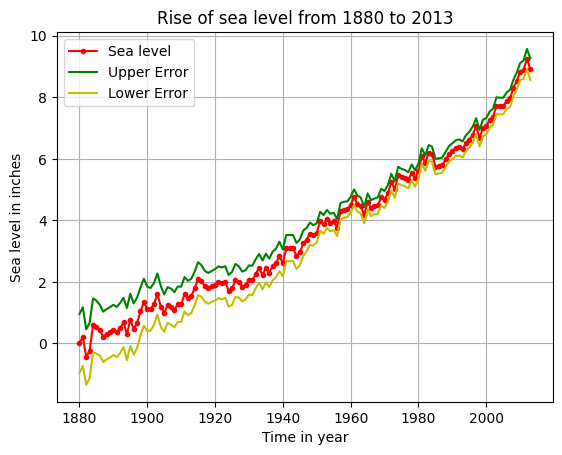

In [ ]:
plt.plot(csiro['Year'], csiro['CSIRO Adjusted Sea Level'],'r.-', # The ajusted sea level in Red
         csiro['Year'], csiro['Upper Error Bound'], 'g', # the Upper error in Green
         csiro['Year'], csiro['Lower Error Bound'], 'y') # the Lower error in yellow

# Set the axis names
plt.xlabel('Time in year')
plt.ylabel('Sea level in inches')

# Add a grid, a title and legends
plt.grid()
plt.title('Rise of sea level from 1880 to 2013')
plt.legend(['Sea level','Upper Error','Lower Error'])


It seems that the sea level has been going up for the last 120 years.
The ajusted sea level is clearly between the upper and the lower error.

# 3. Predictions

In [ ]:
lreg = linregress(csiro['Year'],csiro['CSIRO Adjusted Sea Level'])

In [ ]:
slope,y_intercept = lreg.slope,lreg.intercept
print('slope=',slope,'y=',y_intercept)


slope= 0.0628765374624721 y= -118.74277636667209


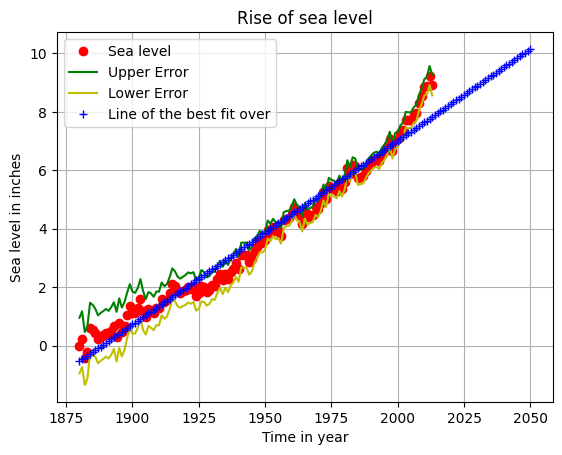

In [ ]:
plt.plot(csiro['Year'], csiro['CSIRO Adjusted Sea Level'],'ro', # The ajusted sea level in Red
         csiro['Year'], csiro['Upper Error Bound'],'g', # the Upper error in Green
         csiro['Year'], csiro['Lower Error Bound'],'y') # the Lower error in yellow

# Create a Pandas Series containing all the years from 2014 to 2050
future_years = pd.Series(list(range(2050 - csiro['Year'].max()))) + csiro['Year'].max()+1

# Concatenate the previous series along with the other years So that we could have a series that goes from 1880 to 2050
Beginning_to_2050 = pd.Series(list(csiro['Year']) + list(future_years))

# Plot the line of best linear fit
plt.plot(Beginning_to_2050 , slope * Beginning_to_2050 + y_intercept,'b+')

# Labels on the axis
plt.xlabel('Time in year')
plt.ylabel('Sea level in inches')

# Grid, Title and legends
plt.grid()
plt.title('Rise of sea level')
plt.legend(['Sea level','Upper Error','Lower Error','Line of the best fit over'])

plt.savefig('sea_level_plot.png')

By the year 2050 the sea level is expected to reach 10 inches (0.254 meters ) if things keep going the same way as during the last 120 years